# Diabetes Prediction

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("/content/diabetes.csv")

In [24]:
print("Dataset Info:")
display(df.info())

print("\nDataset Head:")
display(df.head())

print("\nDataset Shape:")
display(df.shape)

print("\nDataset Columns:")
display(df.columns)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None


Dataset Head:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:


(768, 9)


Dataset Columns:


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

### Observations from Dataset Inspection:

*   **Dimensions:** The dataset contains 768 rows and 9 columns.
*   **Column Names:** The columns are: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome`.
*   **Data Types:** All columns appear to be numerical, with `Outcome` being an integer type (likely 0 or 1 for binary classification) and the rest are either integers or floats.
*   **Missing Values:** Based on `df.info()`, there are no explicit `NaN` values, as all columns show 768 non-null entries. However, columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` have a minimum value of 0, which could represent missing or invalid data, as these values typically cannot be zero in a biological context. This will need further investigation during data cleaning.

In [25]:
print("Descriptive Statistics for Numerical Variables:")
display(df.describe())

Descriptive Statistics for Numerical Variables:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Observations from Descriptive Statistics:

*   **Pregnancies:** The number of pregnancies ranges from 0 to 17, with a mean of around 3.8 and a median of 3. This distribution appears right-skewed.
*   **Glucose:** Glucose levels range from 0 to 199. A minimum of 0 is biologically implausible and suggests missing data, which will need to be addressed. The mean is around 120.9, and the median is 117.
*   **BloodPressure:** Blood pressure ranges from 0 to 122. Similar to Glucose, a minimum of 0 is not medically possible, indicating missing data. The mean is around 69.1, and the median is 72.
*   **SkinThickness:** Skin thickness ranges from 0 to 99. A minimum of 0 also suggests missing data. The mean is around 20.5, and the median is 23.
*   **Insulin:** Insulin levels range from 0 to 846. A minimum of 0 is expected for some individuals, but a large number of 0s might indicate missing values or non-diabetic individuals. The mean is around 79.8, with a median of 30, suggesting a heavily right-skewed distribution and many zero values.
*   **BMI:** BMI ranges from 0 to 67.1. A minimum of 0 is clinically impossible and indicates missing data. The mean is around 32, and the median is 32. It's important to impute these zero values.
*   **DiabetesPedigreeFunction:** This genetic predisposition score ranges from 0.078 to 2.42, with a mean of 0.47 and a median of 0.37. It is right-skewed.
*   **Age:** Age ranges from 21 to 81, with a mean of around 33 and a median of 29. The distribution appears right-skewed.
*   **Outcome:** This is a binary variable (0 for non-diabetic, 1 for diabetic). The mean of 0.348 indicates that approximately 34.8% of the individuals in the dataset are diabetic.

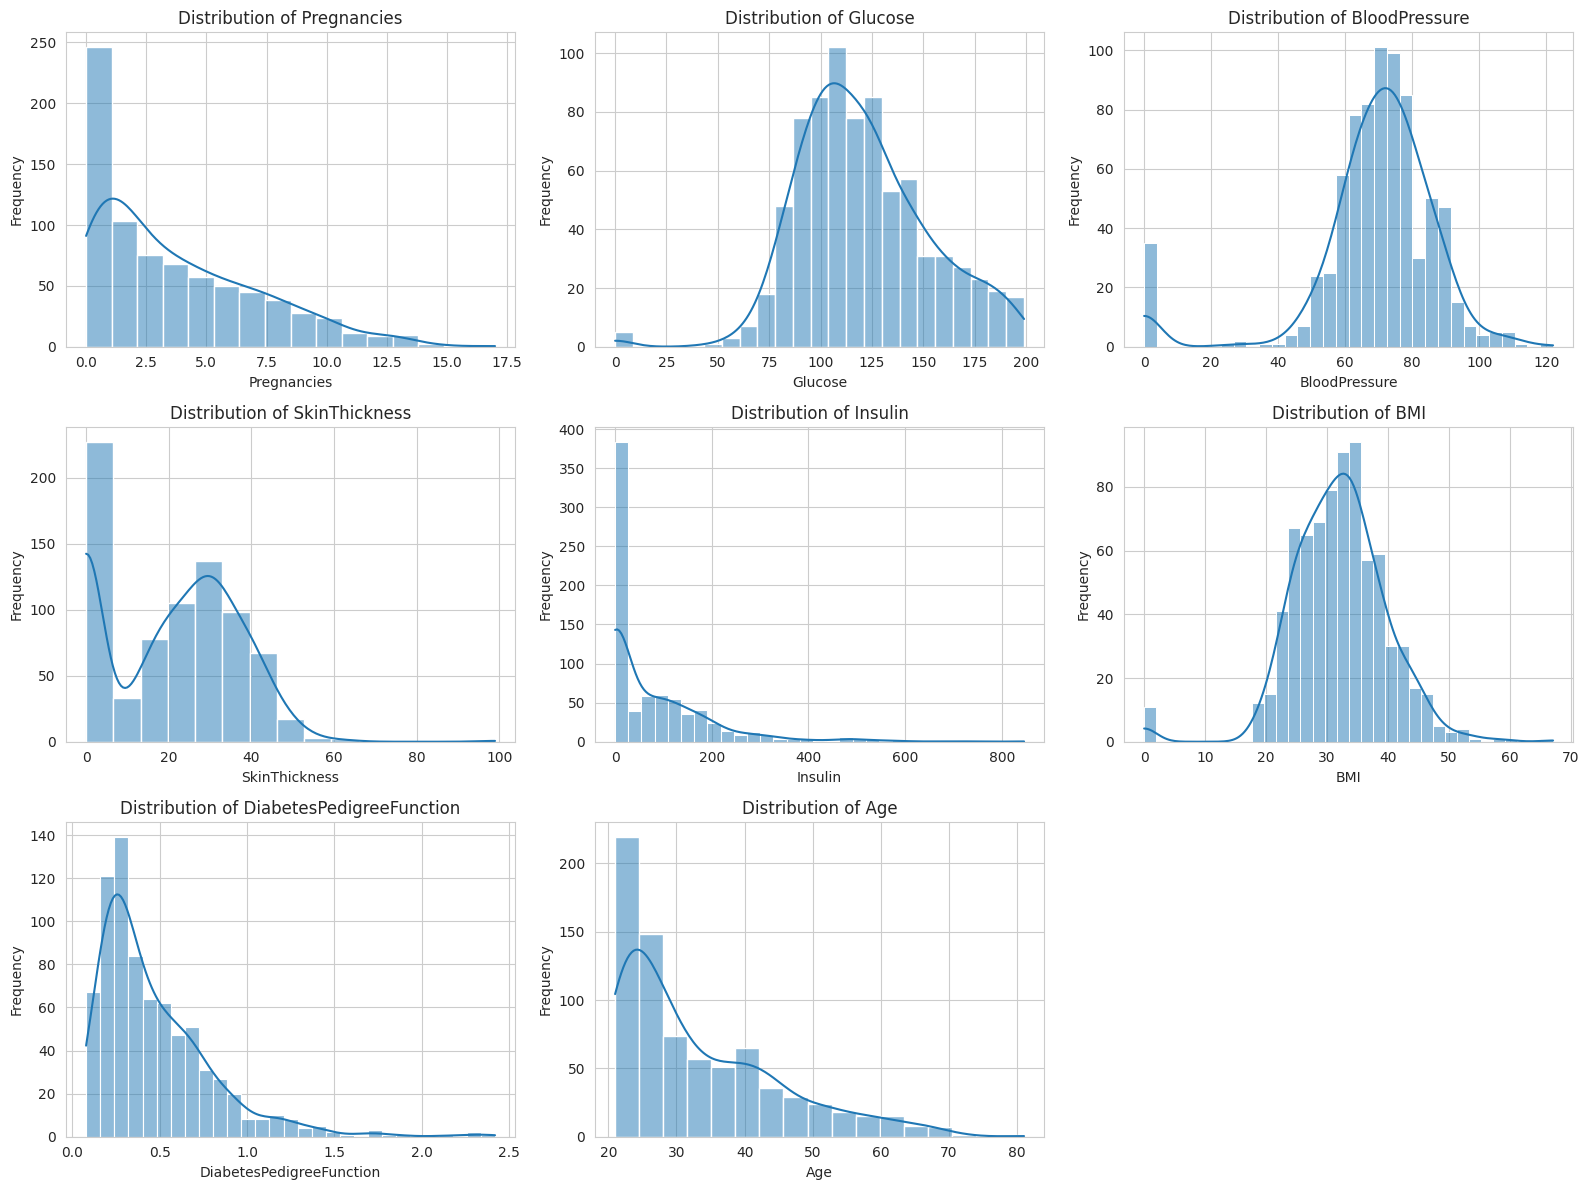

In [27]:
# Set the style for the plots
sns.set_style("whitegrid")

# Identify numerical columns for distribution analysis (excluding 'Outcome')
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Create histograms for numerical features
plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

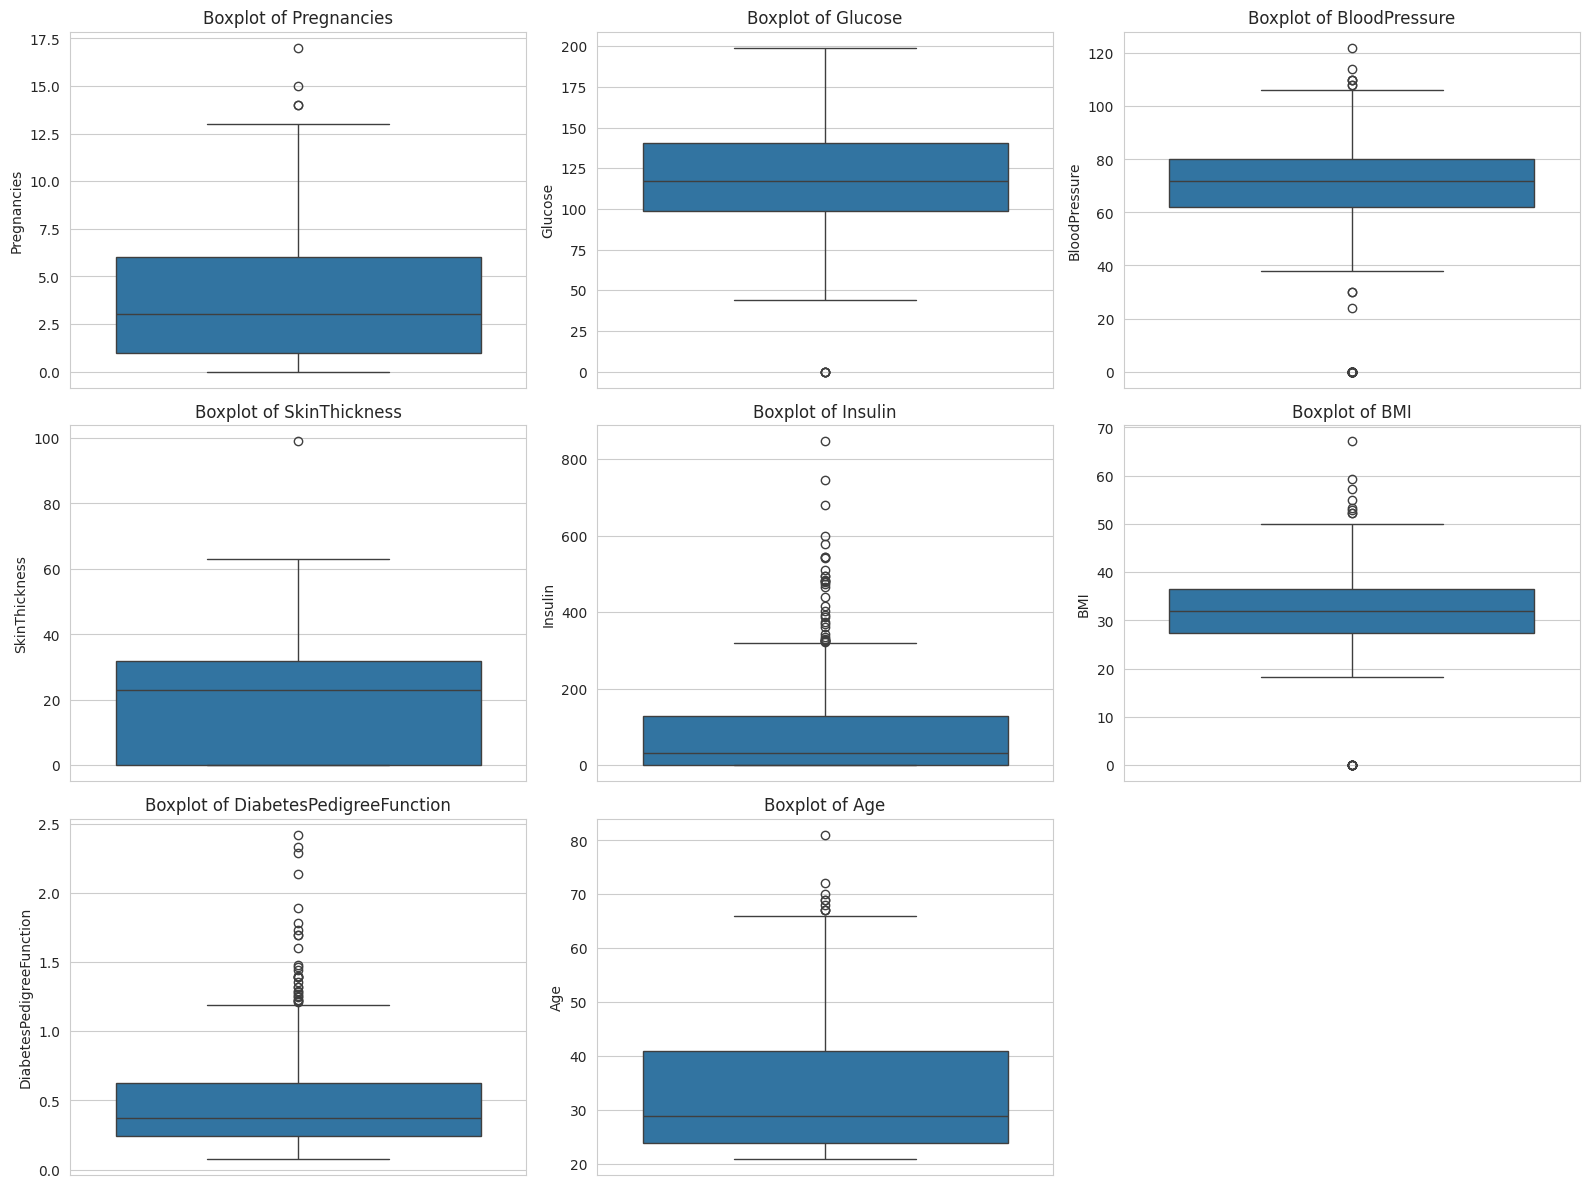

In [28]:
# Create boxplots for numerical features to identify outliers
plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Observations from Histograms and Boxplots:

*   **Histograms:**
    *   `Pregnancies`, `DiabetesPedigreeFunction`, `Age`, and `Insulin` show right-skewed distributions, with a concentration of values towards the lower end and a tail extending to the right.
    *   `Glucose`, `BloodPressure`, `SkinThickness`, and `BMI` show distributions that are somewhat bell-shaped but still have noticeable skewness, especially due to the high frequency of zero values.
    *   The presence of zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` is clearly visible as large bars at zero, confirming our earlier observation from descriptive statistics that these might represent missing data.

*   **Boxplots:**
    *   Most variables (`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`) display a significant number of outliers, indicated by points beyond the whiskers.
    *   The extreme outliers, particularly in `Insulin`, `Pregnancies`, `DiabetesPedigreeFunction`, and `Age`, suggest that these variables have values far from the central tendency, which might require further investigation or handling during preprocessing.
    *   The boxplots also reinforce the issue of zero values, as they appear as the minimum (or close to minimum) values for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`.

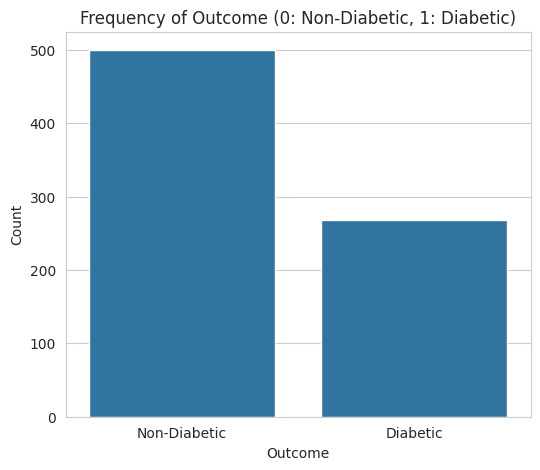

Outcome Variable Value Counts:


,count
Outcome,
0,500
1,268


In [29]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Outcome', data=df)
plt.title('Frequency of Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic', 'Diabetic'])
plt.show()

print("Outcome Variable Value Counts:")
display(df['Outcome'].value_counts())

### Observations from Outcome Variable Frequency:

*   The bar chart clearly shows the distribution of the 'Outcome' variable.
*   There are significantly more instances of 'Non-Diabetic' (Outcome = 0) than 'Diabetic' (Outcome = 1).
*   Specifically, there are 500 non-diabetic individuals and 268 diabetic individuals.
*   This indicates that the dataset is imbalanced, which is an important consideration for model training. Imbalanced datasets can lead to models that perform well on the majority class but poorly on the minority class. This might require techniques like oversampling, undersampling, or using specific evaluation metrics during machine learning model development.

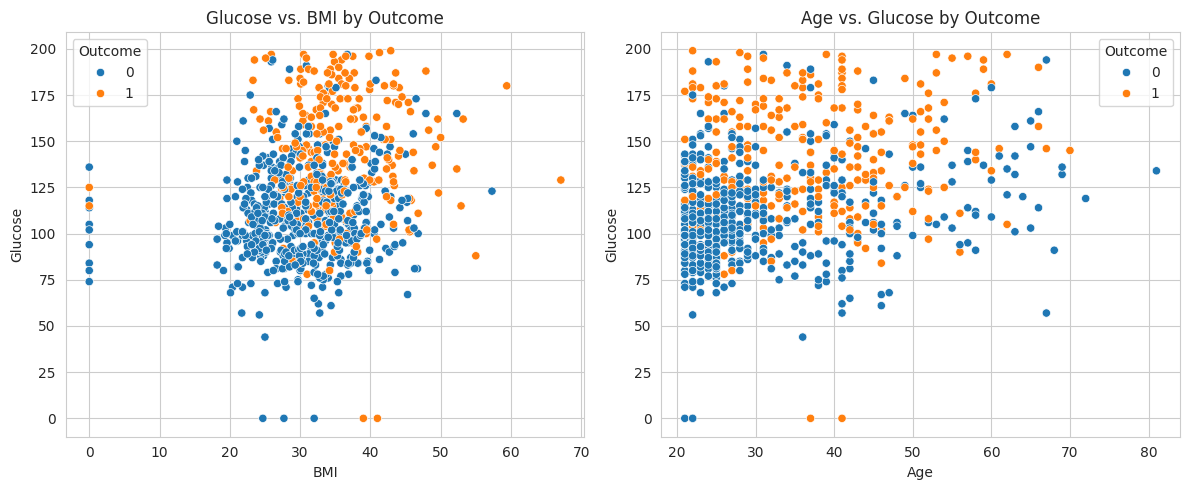

In [30]:
plt.figure(figsize=(12, 5))

# Scatter plot for Glucose vs. BMI
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df)
plt.title('Glucose vs. BMI by Outcome')
plt.xlabel('BMI')
plt.ylabel('Glucose')

# Scatter plot for Age vs. Glucose
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x='Age', y='Glucose', hue='Outcome', data=df)
plt.title('Age vs. Glucose by Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')

plt.tight_layout()
plt.show()

### Observations from Scatter Plots:

*   **Glucose vs. BMI:**
    *   We observe a general positive trend: as BMI increases, Glucose levels tend to increase. This suggests a correlation between higher BMI and higher glucose levels, which is expected as obesity is a risk factor for diabetes.
    *   Diabetic individuals (Outcome = 1, typically shown in a different color) appear to be more concentrated in the higher ranges of both BMI and Glucose compared to non-diabetic individuals (Outcome = 0).
    *   The points where Glucose or BMI are 0 (which we identified as potential missing values) are visible, primarily along the axes, and they do not contribute meaningfully to the relationship between the two variables.

*   **Age vs. Glucose:**
    *   There is a general tendency for Glucose levels to increase with Age, indicating a positive correlation. This is also expected, as the risk of diabetes increases with age.
    *   Similar to the Glucose vs. BMI plot, diabetic individuals (Outcome = 1) are more prevalent among older age groups and higher glucose levels.
    *   The zero values for Glucose are also present here, which again indicates data anomalies.

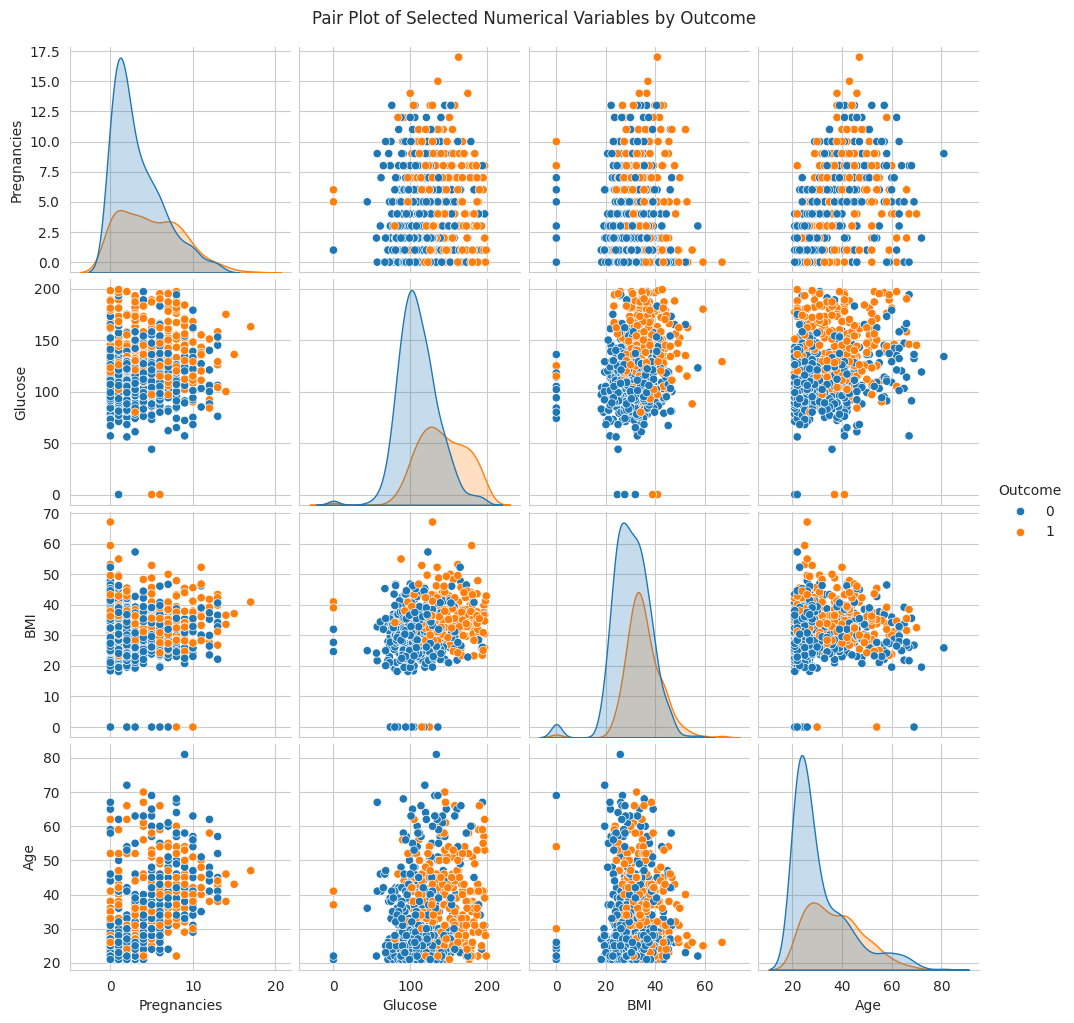

In [31]:
# Select a subset of numerical columns for the pair plot to keep it readable
# Exclude 'Outcome' for the pair plot matrix, but use it as hue
pair_plot_cols = ['Pregnancies', 'Glucose', 'BMI', 'Age', 'Outcome']
sns.pairplot(df[pair_plot_cols], hue='Outcome', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Numerical Variables by Outcome', y=1.02) # Adjust suptitle position
plt.show()

### Observations from Pair Plot:

*   **Diagonal (Histograms/KDEs):** These plots show the distribution of each variable, separated by the `Outcome`. They reinforce observations from individual histograms: `Pregnancies`, `BMI`, `Age`, and `Glucose` distributions differ between diabetic and non-diabetic groups.
    *   For instance, diabetic individuals (Outcome=1) tend to have higher `Glucose` levels, higher `BMI`, and are generally older or have more `Pregnancies`.
*   **Off-Diagonal (Scatter Plots):** These plots show the relationships between each pair of variables, again colored by `Outcome`.
    *   **Glucose vs. BMI, Glucose vs. Age:** These plots clearly show a positive correlation, where higher `Glucose` levels are associated with higher `BMI` and `Age`. Diabetic individuals are predominantly found in the regions where both variables are high.
    *   **Pregnancies vs. Age:** There's a visible correlation, as expected, with older women generally having more pregnancies.
    *   **Other Relationships:** While some relationships are clearer, others are less distinct, but the separation by 'Outcome' often reveals clusters or patterns that differentiate the two groups.

Overall, the pair plot provides a comprehensive visual summary, highlighting the complex interdependencies among features and their collective influence on the `Outcome` variable, particularly the tendency for individuals with higher values in `Glucose`, `BMI`, `Age`, and `Pregnancies` to be diabetic.